# ADC Fitting Workflow with Digital Reference Objects

This notebook demonstrates how to use Digital Reference Objects (DROs) for validating ADC (Apparent Diffusion Coefficient) fitting algorithms.

## Learning Objectives

- Understand the mono-exponential diffusion model
- Generate synthetic DWI data with known ground truth
- Fit ADC using different methods (LLS, WLLS, IWLLS)
- Validate fitting accuracy against ground truth

## Background

The ADC is derived from diffusion-weighted imaging (DWI) using the Stejskal-Tanner equation:

$$S(b) = S_0 \exp(-b \cdot \text{ADC})$$

where:
- $S(b)$ is the signal at diffusion weighting $b$
- $S_0$ is the baseline signal (at $b=0$)
- ADC is the Apparent Diffusion Coefficient in mm²/s

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qmri.diffusion import adc
from qmri.dro import dwi

## 1. Single-Voxel ADC Fitting

Let's start by generating a single-voxel phantom with a known ADC value and fitting it.

In [2]:
# Generate a phantom with known ADC (typical grey matter value)
true_adc = 1.0e-3  # mm²/s
phantom = dwi.generate(
    adc=true_adc,
    s0=1000.0,
    b_values=(0, 500, 1000, 2000),
    snr=50.0,
    seed=42,
)

print(f"Ground truth ADC: {phantom.ground_truth['adc'].value:.2e} mm²/s")
print(f"b-values: {phantom.b_values}")
print(f"Signal: {phantom.signal.round(1)}")

Ground truth ADC: 1.00e-03 mm²/s
b-values: [   0.  500. 1000. 2000.]
Signal: [1003.4  595.7  375.8  145.3]


In [3]:
# Fit ADC using IWLLS (recommended method)
result = adc.fit(phantom.signal, phantom.b_values, method="iwlls")

print(f"Fitted ADC: {result.adc:.2e} mm²/s")
print(f"Fitted S0: {result.s0:.1f}")
print(f"R²: {result.r_squared:.4f}")
print(f"Error: {100 * (result.adc - true_adc) / true_adc:.1f}%")

Fitted ADC: 9.91e-04 mm²/s
Fitted S0: 998.5
R²: 0.9993
Error: -0.9%


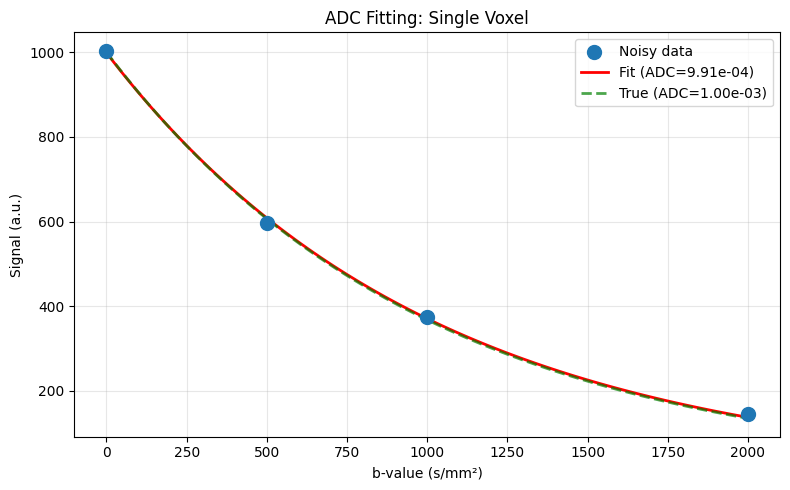

In [4]:
# Visualise the fit
fig, ax = plt.subplots(figsize=(8, 5))

# Plot data points
ax.scatter(phantom.b_values, phantom.signal, s=100, zorder=3, label="Noisy data")

# Plot fitted curve
b_fine = np.linspace(0, 2000, 100)
s_fit = result.s0 * np.exp(-b_fine * result.adc)
ax.plot(b_fine, s_fit, "r-", linewidth=2, label=f"Fit (ADC={result.adc:.2e})")

# Plot true curve
s_true = 1000 * np.exp(-b_fine * true_adc)
ax.plot(
    b_fine, s_true, "g--", linewidth=2, alpha=0.7, label=f"True (ADC={true_adc:.2e})"
)

ax.set_xlabel("b-value (s/mm²)")
ax.set_ylabel("Signal (a.u.)")
ax.set_title("ADC Fitting: Single Voxel")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Multi-Voxel ADC Fitting

Now let's create a grid of voxels with different ADC values and visualise the error maps.

In [5]:
# Create a 2D ADC map with different tissue types
adc_map = np.array(
    [
        [0.3e-3, 0.5e-3, 0.7e-3, 1.0e-3],  # Restricted to GM
        [0.5e-3, 0.7e-3, 1.0e-3, 1.5e-3],  # WM to less restricted
        [0.7e-3, 1.0e-3, 1.5e-3, 2.0e-3],  # GM to CSF-like
        [1.0e-3, 1.5e-3, 2.0e-3, 3.0e-3],  # GM to free water
    ]
)

# Generate multi-voxel phantom
phantom_2d = dwi.generate(
    adc=adc_map,
    s0=1000.0,
    b_values=(0, 500, 1000, 2000),
    snr=50.0,
    seed=42,
)

print(f"Phantom shape: {phantom_2d.signal.shape}")

Phantom shape: (4, 4, 4)


In [6]:
# Fit ADC for each voxel
result_2d = adc.fit(phantom_2d.signal, phantom_2d.b_values, method="iwlls")

# Calculate error map
error_map = 100 * (result_2d.adc - adc_map) / adc_map

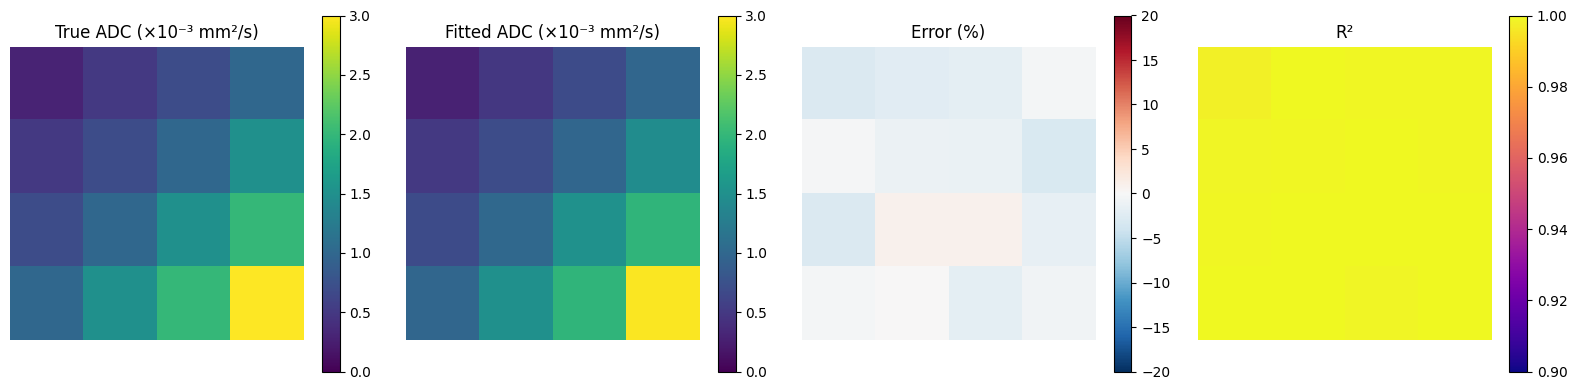

Mean absolute error: 1.4%


In [7]:
# Visualise results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# True ADC
im0 = axes[0].imshow(adc_map * 1e3, cmap="viridis", vmin=0, vmax=3)
axes[0].set_title("True ADC (×10⁻³ mm²/s)")
plt.colorbar(im0, ax=axes[0])

# Fitted ADC
im1 = axes[1].imshow(result_2d.adc * 1e3, cmap="viridis", vmin=0, vmax=3)
axes[1].set_title("Fitted ADC (×10⁻³ mm²/s)")
plt.colorbar(im1, ax=axes[1])

# Error map
im2 = axes[2].imshow(error_map, cmap="RdBu_r", vmin=-20, vmax=20)
axes[2].set_title("Error (%)")
plt.colorbar(im2, ax=axes[2])

# R² map
im3 = axes[3].imshow(result_2d.r_squared, cmap="plasma", vmin=0.9, vmax=1)
axes[3].set_title("R²")
plt.colorbar(im3, ax=axes[3])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Mean absolute error: {np.mean(np.abs(error_map)):.1f}%")

## 3. Clinical Context: Typical ADC Values

Here are typical ADC values for different tissues at 3T:

| Tissue | ADC (×10⁻³ mm²/s) |
|--------|-------------------|
| Grey matter | 0.8 - 1.0 |
| White matter | 0.6 - 0.8 |
| CSF | 2.5 - 3.0 |
| Acute stroke | 0.3 - 0.5 |
| Tumour | Variable |

In [8]:
# Generate calibration phantom with clinical ADC values
clinical_adc_values = [0.4e-3, 0.7e-3, 0.9e-3, 1.5e-3, 2.8e-3]
tissue_labels = ["Acute stroke", "White matter", "Grey matter", "Oedema", "CSF"]

# Generate and fit
cal_phantom = dwi.generate(
    adc=np.array(clinical_adc_values),
    snr=100.0,
    seed=42,
)

print("Tissue ADC Validation:")
print("-" * 60)
for i, (tissue, true_val) in enumerate(zip(tissue_labels, clinical_adc_values)):
    fit_result = adc.fit(cal_phantom.signal[i], cal_phantom.b_values)
    error = 100 * (fit_result.adc - true_val) / true_val
    print(
        f"{tissue:15} True: {true_val * 1e3:.2f}  Fitted: {fit_result.adc * 1e3:.2f}  Error: {error:+.1f}%"
    )

Tissue ADC Validation:
------------------------------------------------------------
Acute stroke    True: 0.40  Fitted: 0.40  Error: -1.2%
White matter    True: 0.70  Fitted: 0.69  Error: -0.8%
Grey matter     True: 0.90  Fitted: 0.89  Error: -0.8%
Oedema          True: 1.50  Fitted: 1.49  Error: -0.8%
CSF             True: 2.80  Fitted: 2.82  Error: +0.8%


## Summary

In this notebook we demonstrated:

1. **Single-voxel fitting**: Generate synthetic signal → add noise → fit → validate
2. **Multi-voxel fitting**: Create ADC grids and visualise error maps
3. **Clinical context**: Typical ADC values for different tissues

DROs are invaluable for:
- Validating fitting algorithms against known ground truth
- Understanding how noise affects ADC estimation
- Testing new acquisition protocols before clinical use